In [1]:
import warnings
import time

import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines

import os

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

from scipy.stats import norm, t, probplot, pearsonr
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# import thetaflow as thf
import modelnn2 as thf

2026-03-20 23:16:13.909834: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774059373.927876   10744 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774059373.933840   10744 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774059373.948214   10744 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774059373.948241   10744 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774059373.948242   10744 computation_placer.cc:177] computation placer alr

In this notebook, we attempt to use thetaflow to replicate the exact structure used in Cox-nnet. An implementation for the Cox model, where the inputs are actually the outputs of a dense neural network.

In [2]:
# Count DSeq2 transformed matrix passed to the vsd in R
df = pd.read_csv("tcga_brca_count_data.csv")
X = df.iloc[:,2:]

print("Data dimensions: {}".format(df.shape))
df.head()

Data dimensions: (1071, 17229)


,time,delta,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,...,ENSG00000286264.2,ENSG00000286522.2,ENSG00000287080.2,ENSG00000287725.1,ENSG00000288534.1,ENSG00000288558.2,ENSG00000288611.1,ENSG00000288658.1,ENSG00000288674.1,ENSG00000288675.1
0,652,0,-1.853176,-0.470929,-0.131276,-0.041381,-0.444749,1.461567,0.417750,-0.237293,...,0.231436,-0.313115,0.151611,-0.064308,0.144261,0.417327,-0.134809,-0.187306,0.049695,0.290726
1,1246,0,-0.966379,0.086426,1.200473,-0.465156,-0.260696,-0.186921,-0.792181,1.199625,...,0.053848,0.754586,1.174240,-0.557631,0.406049,-0.180344,-0.157223,-0.356713,-0.224750,0.252724
2,90,0,-0.760327,-0.290147,-0.187316,-0.315453,-1.016765,-0.861385,0.698055,0.148165,...,-0.231558,0.652401,0.979677,-0.555933,-0.218687,-0.200427,0.069668,-0.660348,-0.528385,0.049268
3,1471,0,-0.267662,-0.375111,-0.144823,0.168895,-0.908310,0.136620,0.334530,-0.160932,...,0.071604,-0.648352,-0.514442,-0.227771,-0.055488,-0.186406,-0.372123,-0.660348,-0.235285,0.464834
4,172,1,-1.418467,-0.296171,0.170526,0.116932,-0.594098,-0.868466,0.601509,0.704029,...,-0.234443,0.127458,0.037402,-0.464857,-0.170034,0.078319,-0.032907,0.627791,-0.049754,0.116094


In [3]:
X = df.iloc[:,2:]

# y = tf.cast( df.iloc[:,0].to_numpy()/365, dtype = tf.float32 )
y = df.loc[:,"time"].to_numpy()/365
# delta = tf.cast( df.iloc[:,1].to_numpy(), dtype = tf.float32 )
delta = df.loc[:,"delta"].to_numpy()
data = [tf.constant(y, shape = (len(y), 1), dtype = tf.float32), tf.constant(delta, shape = (len(delta), 1), dtype = tf.float32)]

In [4]:
X_train, X_test, y_train, y_test, delta_train, delta_test = train_test_split(X.to_numpy(), y, delta, test_size = 0.2, random_state = 10)

X_train = tf.cast(X_train, dtype = tf.float32)
X_test = tf.cast(X_test, dtype = tf.float32)
data_train = [tf.constant(y_train, shape = (len(y_train), 1), dtype = tf.float32), tf.constant(delta_train, shape = (len(delta_train), 1), dtype = tf.float32)]
data_test = [tf.constant(y_test, shape = (len(y_test), 1), dtype = tf.float32), tf.constant(delta_test, shape = (len(delta_test), 1), dtype = tf.float32)]

2026-03-20 23:16:23.963180: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 117970496 exceeds 10% of free system memory.
2026-03-20 23:16:24.233055: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29630440 exceeds 10% of free system memory.


In [5]:
cox_nnet_parameters = {
    "theta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": 0.0},
}

def cox_nnet_partial_loglikelihood_loss(model, nn_output, data):
    # Unpack your data tuple
    X, y, delta = data
    
    theta = model.get_variable("theta", nn_output)
    
    # 1. Standardize shapes to (N, 1) for safe broadcasting and matrix operations
    y_col = tf.reshape(y, [-1, 1])
    y_row = tf.reshape(y, [1, -1])
    theta_col = tf.reshape(theta, [-1, 1])
    delta_col = tf.reshape(delta, [-1, 1])

    # 2. The Indicator Matrix 'R' Trick
    # R[i, j] = 1 if patient j survived as long as, or longer than, patient i (t_j >= t_i)
    # This matrix completely eliminates the need for a nested loop over the risk set
    R_matrix = tf.cast(y_row >= y_col, dtype = tf.float32)

    # 3. Calculate the risk scores
    exp_theta = tf.math.exp(theta_col)

    # 4. Matrix multiplication instantly sums the risk scores for all valid patients in the risk set
    # risk_sum[i] = sum(exp(theta_j)) for all j where y_j >= y_i
    risk_sum = tf.matmul(R_matrix, exp_theta)

    # 5. Calculate the log of the risk sum 
    # (Adding the 1e-7 epsilon shield to prevent log(0) at the final censored event)
    log_risk_sum = tf.math.log(risk_sum + 1e-7)

    # 6. Calculate the partial log-likelihood
    # Multiply by delta_col so that censored patients (delta=0) do not contribute to the outer sum
    pll = tf.reduce_sum(delta_col * (theta_col - log_risk_sum))

    # Return the negative partial log-likelihood because TensorFlow optimizers always minimize
    return -pll

def cox_nnet_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    ridge = tf.keras.regularizers.L2(l2 = 1.0e-2)
    
    # 1. The Hidden Layer (Feature Extractor)
    model.dense1 = layers.Dense(
        units = 169,
        activation = "tanh",     
        kernel_initializer = initializer,
        kernel_regularizer = ridge,
        use_bias = True,         # Hidden nodes need biases (the 'b' in the formula)
        dtype = tf.float32, 
        name = "latent_representation"
    )
    
    # 2. The Dropout Layer
    model.dropout = layers.Dropout(rate = 0.1, seed = seed)
    
    # 3. The Cox Beta Layer (The brilliant realization)
    model.output_layer = layers.Dense(
        units = 1, 
        activation = None,       # Linear pass-through
        use_bias = False,        # CRITICAL: No intercept, making these weights pure beta coefficients
        kernel_initializer = initializer,
        kernel_regularizer = ridge,
        dtype = tf.float32,
        name = "beta_coefficients"
    )

def cox_nnet_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dropout(x, training = training)
    return model.output_layer(x) # Returns the final theta scalar for each patient

def cox_nnet_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    return x

In [6]:
with tf.device("/GPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    cox_nnet_model = thf.ModelNN(cox_nnet_parameters, cox_nnet_partial_loglikelihood_loss,
                                 cox_nnet_neural_network, cox_nnet_network_call,
                                 cox_nnet_network_call_nolast, input_dim = (None, X.shape[1]), seed = 10)

    theta_before_pretrain = cox_nnet_model.predict(X)["theta"].numpy().flatten()
    
    cox_nnet_model.pre_train_model(X_train, data_train,
                                   epochs = 1000, shuffle = True,
                                   optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                   verbose = 1, track_time = True)

    theta_after_pretrain = cox_nnet_model.predict(X)["theta"].numpy().flatten()

    cox_nnet_model.train_model(X_train, data_train,
                               epochs = 10000, shuffle = True, metrics_update_freq = 50,
                               fine_tune = False,
                               get_covariances = False,
                               validation = False, val_prop = 0.2,
                               optimizer_nn = optimizers.SGD(learning_rate = 0.1, momentum = 0.9, nesterov = True, clipnorm = 1.0),
                               train_batch_size = None, val_batch_size = None,
                               buffer_size = 4096, gradient_accumulation_steps = None,
                               early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 1000,
                               reduce_lr = True, reduce_lr_warmup = 10,
                               reduce_lr_factor = 0.9, reduce_lr_min_delta = 1.0e-4, reduce_lr_patience = 5,
                               reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
                               deterministic = True,
                               verbose = 1, print_freq = 50)

    theta_after_train = cox_nnet_model.predict(X)["theta"].numpy().flatten()

2026-03-20 20:28:53.435281: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 248486784 exceeds 10% of free system memory.


GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Optimizing... Epoch: [ 600 / 1000 ]  | Loss:  6.37714493e-06 | Param Dist:  0.000653554802 | Independent Learning rate:  0.001 | Network Learning rate:  0.1 | [Speed tracking disabled for determinism]   
Stopping. Model has converged at epoch 700
Optimizing... Epoch: [ 700 / 1000 ]  | Loss:  1.81316796e-06 | Param Dist:  9.43065243e-05 | Independent Learning rate:  0.001 | Network Learning rate:  0.1 | [Speed tracking disabled for determinism]   

2026-03-20 20:29:16.734061: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 248486784 exceeds 10% of free system memory.


GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 9950 / 10000 ]  | Loss:  276.194305 | Param Dist:  2.14132762 | Independent Learning rate:  0.001 | Network Learning rate:  0.0478296801 | [Speed tracking disabled for determinism]   
Done.
Optimization finished in 166.906 seconds.


2026-03-20 20:32:05.065328: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 248486784 exceeds 10% of free system memory.


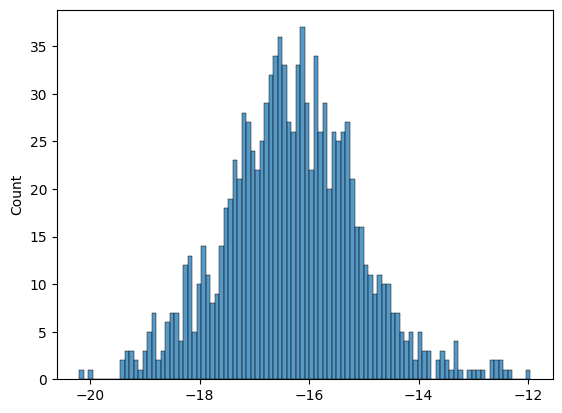

In [7]:
sns.histplot(x = theta_after_train, bins = 100)
plt.show()

In [8]:
from lifelines.utils import concordance_index

# 1. Get the final predictions from your trained model
# (Assuming x_test is your holdout set and model is your compiled keras model)
theta_predictions = cox_nnet_model.predict(X_test)["theta"].numpy().flatten()

# 2. Extract your true survival times (y) and censoring status (delta)
# Make sure delta is boolean or 1/0 (1 = dead/event occurred, 0 = censored)
time_true = y_test.flatten()
event_true = delta_test.flatten()

# 3. Calculate Harrell's C-index
# CRITICAL STATISTICAL NOTE: 
# lifelines' concordance_index expects a predicted *survival time* (higher = lives longer).
# Because your theta is a *hazard ratio* (higher = dies faster), we must negate theta
# to correctly flip the ranking logic, otherwise you will get 1.0 - true_c_index.
c_index = concordance_index(
    event_times = time_true, 
    predicted_scores = -theta_predictions, 
    event_observed = event_true
)

print(f"Harrell's C-index: {c_index:.4f}")

Harrell's C-index: 0.7483


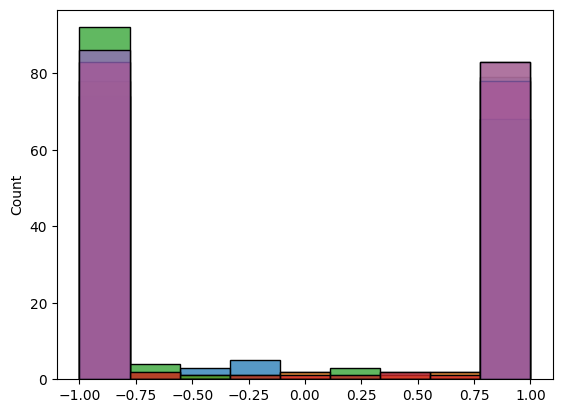

In [9]:
hidden_activations = cox_nnet_network_call_nolast(cox_nnet_model, X_scaled).numpy()
# Plot the hidden layer weights histogram for each of the first 5 patients
for i in range(5):
    sns.histplot(hidden_activations[i, :])

In [33]:
beta_weights.shape

(169, 1)

In [34]:
hidden_activations.shape

(1071, 169)

In [36]:
contributions

array([[-0.3625658 , -0.20602532,  0.4170089 , ..., -0.1359207 ,
         0.0510555 ,  0.2930983 ],
       [-0.3625658 ,  0.20558769, -0.4169517 , ...,  0.12487093,
         0.0510555 , -0.2930983 ],
       [ 0.3625658 , -0.20599318,  0.41696018, ...,  0.1359207 ,
        -0.0510555 , -0.2930983 ],
       ...,
       [-0.3625658 ,  0.20602532, -0.4170089 , ...,  0.1359207 ,
         0.0510555 , -0.29309794],
       [ 0.3625658 ,  0.20119485, -0.4170089 , ..., -0.13592002,
         0.0367314 , -0.2920169 ],
       [-0.3625658 ,  0.20602532, -0.4170089 , ...,  0.1359207 ,
         0.0510555 , -0.29309818]], dtype=float32)

In [29]:
import numpy as np

# Activations from the hidden layer for all patients (1094, 169)
hidden_activations = cox_nnet_network_call_nolast(cox_nnet_model, X_scaled).numpy()

# Beta vector from the Cox model
beta_weights = cox_nnet_model.output_layer.get_weights()[0]

contributions = hidden_activations * beta_weights.T 

contribution_variances = np.var(contributions, axis=0)

# 5. Get the indices of the top 20 most variable nodes
# argsort sorts from lowest to highest, so we take the last 20 and reverse them
top_20_node_indices = np.argsort(contribution_variances)[-20:][::-1]

print("Indices of the Top 20 Most Prognostic Nodes:", top_20_node_indices)

Indices of the Top 20 Most Prognostic Nodes: [ 41  86  75  74  10  38 101  60 121  21   2 156  37  12 164 148 165  58
  64 122]


<Axes: ylabel='Count'>

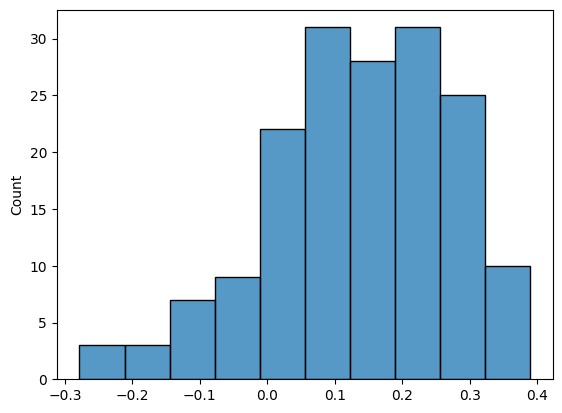

In [140]:
sns.histplot(node_correlations)

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Gather the necessary data 
# (Assuming you just ran the network and have these variables)
hidden_activations = cox_nnet_network_call_nolast(cox_nnet_model, X_scaled).numpy()
beta_weights = cox_nnet_model.output_layer.get_weights()[0].flatten()
theta_predictions = cox_nnet_model.predict(X_scaled)["theta"].numpy()

# Node Contributions (Weighted Activations)
contributions = hidden_activations * beta_weights 

# Sort Patients by Prognostic-Index (Theta)
patient_sort_idx = np.argsort(theta_predictions, axis = 0)
sorted_theta = theta_predictions[patient_sort_idx]
sorted_contributions = contributions[patient_sort_idx, :] 

# 4. Calculate the Pearson Correlation between each node's contribution and the PI
node_correlations = []
for k in range( len(beta_weights) ):
    corr, _ = pearsonr(contributions[:, k], theta_predictions[:,0])
    node_correlations.append(corr)
node_correlations = np.array(node_correlations)

# 5. Prepare DataFrames for Seaborn
# We transpose the matrix so Nodes are Rows (55) and Patients are Columns (N)
df_plot = pd.DataFrame(sorted_contributions[:,0,:].T)

# 6. Create Color Annotations for the Axes
# Create the top bar (Patient PI): Blue for low risk, Red for high risk
pi_norm = mcolors.Normalize(vmin=sorted_theta.min(), vmax=sorted_theta.max())
pi_cmap = plt.get_cmap('bwr')
col_colors = [pi_cmap(pi_norm(val)) for val in sorted_theta]

# Create the side bar (Node Correlation): Blue for negative, Red for positive correlation
corr_norm = mcolors.Normalize(vmin=-1, vmax=1)
corr_cmap = plt.get_cmap('jet') # The paper uses a rainbow-like colormap here
row_colors = [corr_cmap(corr_norm(val)) for val in node_correlations]

# 7. Generate the Clustermap
# We cluster the rows (nodes) but strictly DO NOT cluster columns (patients) 
# because patients must remain ordered by their PI.
# g = sns.clustermap(
#     df_plot,
#     cmap="bwr",                 # Blue-White-Red diverging colormap for the main heatmap
#     row_cluster=True,           # Adds the dendrogram on the left for nodes
#     col_cluster=False,          # Keeps patients sorted strictly by PI
#     row_colors=row_colors,      # Adds the correlation color bar on the left
#     col_colors=col_colors,      # Adds the PI color bar on the top
#     figsize=(14, 10),
#     xticklabels=False,          # Hide patient indices (too cluttered)
#     yticklabels=False,          # Hide node indices 
#     center=0,                   # Centers the colormap at 0 contribution
#     robust=True                 # Prevents extreme outliers from washing out the colors
# )

# # 8. Add Titles and Adjust Layout
# g.fig.suptitle("Hidden layer node outputs (Weighted by Beta)", fontsize=16, y=1.02)
# g.ax_heatmap.set_xlabel("Patients (Ordered by Prognostic Index)")
# g.ax_heatmap.set_ylabel("Hidden Nodes (Clustered)")

# plt.show()

In [169]:
pi_norm(sorted_theta[-3])

np.float32(0.8588156)

In [190]:
sorted_contributions

array([[-0.3592964 , -0.20602532, -0.41032103, ..., -0.13565786,
        -0.04471873, -0.2930983 ],
       [-0.3625658 , -0.20602532, -0.41686675, ..., -0.1359207 ,
        -0.0510555 , -0.2930983 ],
       [ 0.3625658 , -0.20602177, -0.4170089 , ..., -0.1359207 ,
        -0.0510551 , -0.2930983 ],
       ...,
       [ 0.36256558, -0.20602532,  0.41700768, ..., -0.1359207 ,
         0.0510555 ,  0.2930983 ],
       [ 0.3625658 ,  0.20602532,  0.4170089 , ...,  0.1359207 ,
         0.0510555 ,  0.2930983 ],
       [ 0.36256525,  0.20602478,  0.4168905 , ...,  0.13581179,
         0.0510555 ,  0.2930983 ]], dtype=float32)

/home/natan/.pyenv/versions/3.10.17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


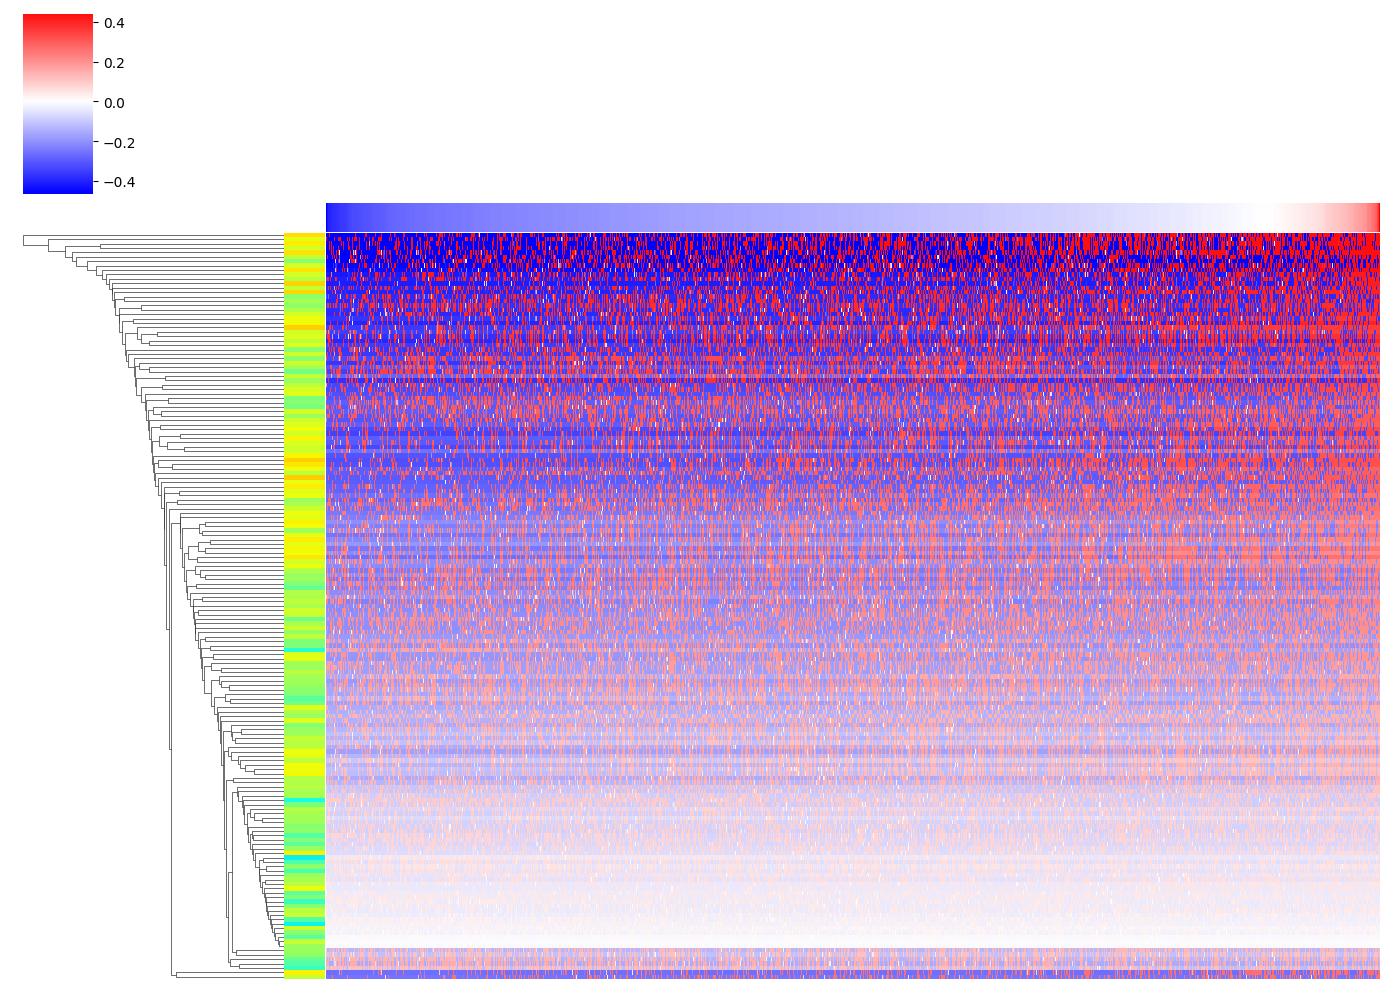

In [215]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.colors as mcolors

hidden_activations = cox_nnet_network_call_nolast(cox_nnet_model, X_scaled).numpy()
beta_weights = cox_nnet_model.output_layer.get_weights()[0].flatten()
theta_predictions = cox_nnet_model.predict(X_scaled)["theta"].numpy().flatten() 

# Node Contributions (Weighted Activations)
contributions = hidden_activations * beta_weights 

# Sort Patients by Prognostic-Index (Theta)
patient_sort_idx = np.argsort(theta_predictions)
sorted_theta = theta_predictions[patient_sort_idx]
sorted_contributions = contributions[patient_sort_idx, :] 

# 4. Calculate the Pearson Correlation 
node_correlations = []
for k in range(len(beta_weights)):
    corr, _ = pearsonr(contributions[:, k], theta_predictions)
    node_correlations.append(corr)
node_correlations = np.array(node_correlations)

# 5. Prepare DataFrame for Seaborn
# Clean 2D transpose: Nodes as Rows (55), Patients as Columns (N)
df_plot = pd.DataFrame(sorted_contributions.T)

# 6. Create Color Annotations 
pi_norm = mcolors.Normalize(vmin = sorted_theta.min(), vmax = sorted_theta.max())
pi_cmap = plt.get_cmap('bwr')
# Because sorted_theta is 1D, 'val' is a clean float, returning a perfect RGBA tuple
col_colors = [pi_cmap(pi_norm(val)) for val in sorted_theta]

# corr_norm = mcolors.Normalize(vmin=-1, vmax=1)
# corr_cmap = plt.get_cmap('jet') 
# row_colors = [corr_cmap(corr_norm(val)) for val in node_correlations]

# fig, ax = plt.subplots(nrows = 2, ncols = 2, gridspec_kw = {'height_ratios': [10, 1], 'width_ratios': [10, 1]})

# 7. Generate the Clustermap
g = sns.clustermap(
    df_plot,
    cmap = "bwr",
    row_cluster = True,
    col_cluster = False,
    row_colors = row_colors,
    col_colors = col_colors,
    figsize = (14, 10),
    xticklabels = False,
    yticklabels = False,
    center = 0,
    robust = True,
)

plt.show()

In [203]:
theta_predictions

array([-7.3162527, -5.6893253, -2.1192605, ..., -3.5833836, -2.2900715,
       -6.4254017], dtype=float32)

<Axes: >

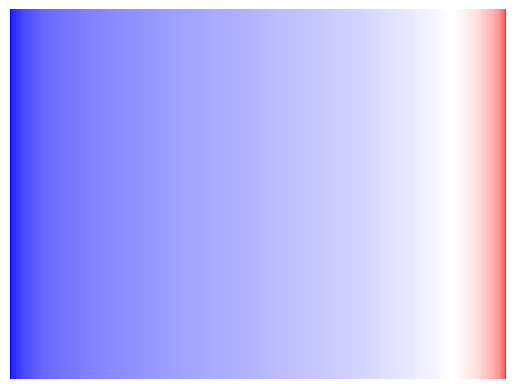

In [216]:
sns.heatmap([np.sort(theta_predictions)], cbar = False, xticklabels = False, yticklabels = False, cmap = "bwr")

<Axes: ylabel='Count'>

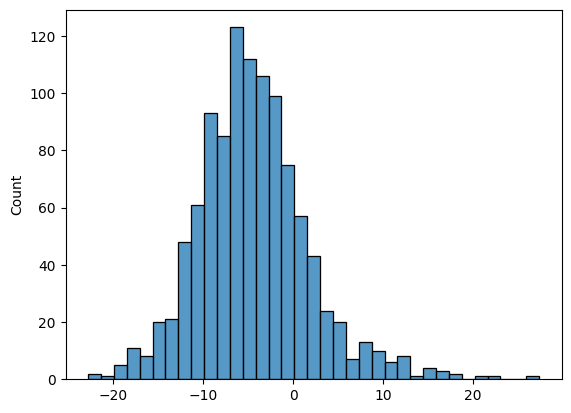

In [205]:
sns.histplot(np.sort(theta_predictions))

<Axes: >

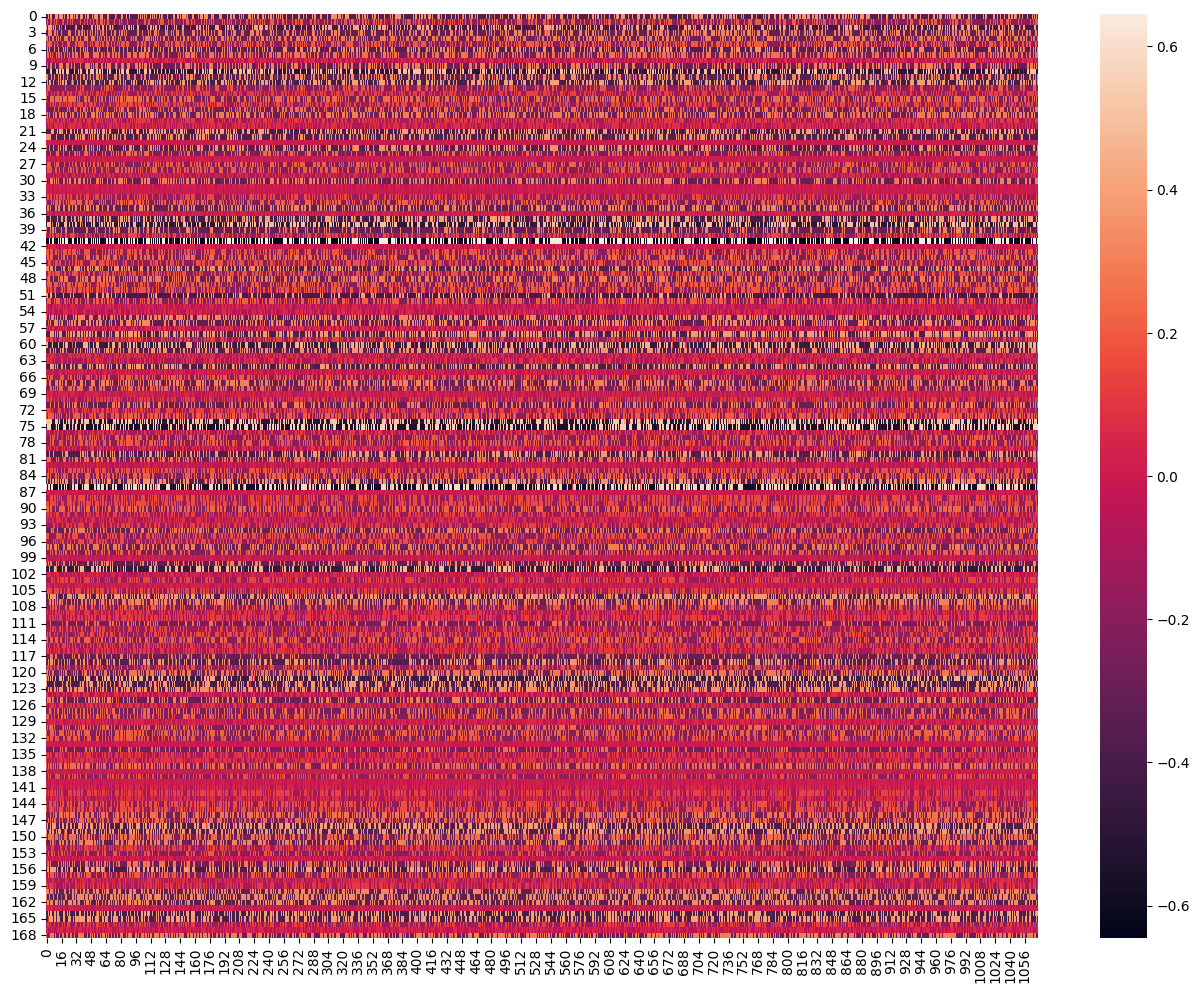

In [188]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (16,12))

sns.heatmap(contributions.T)

In [173]:
df_plot.head(10)

,0,1,2,3,4,5,6,7,8,9,...,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070
0,-0.359296,-0.362566,0.362566,-0.362393,-0.362566,0.362566,-0.357293,-0.362566,-0.362566,0.190090,...,0.362566,0.362566,0.362566,0.362566,0.362566,0.362566,0.362566,0.362566,0.362566,0.362565
1,-0.206025,-0.206025,-0.206022,-0.206025,-0.206023,-0.205823,-0.205986,-0.206025,-0.206025,-0.205358,...,0.206012,0.206025,0.206025,0.206025,0.206025,0.206025,-0.206025,-0.206025,0.206025,0.206025
2,-0.410321,-0.416867,-0.417009,-0.417009,-0.417007,-0.415839,0.250932,-0.417009,-0.417008,-0.417009,...,-0.417009,-0.417007,0.416980,0.417009,-0.417009,0.417009,-0.417009,0.417008,0.417009,0.416891
3,-0.310089,-0.310089,-0.310089,-0.310089,-0.310089,0.310089,0.310089,-0.310089,-0.307942,-0.308804,...,0.310089,0.310089,0.310089,0.310089,0.310089,0.310089,-0.310089,0.310089,-0.310089,0.310089
4,-0.285013,-0.256464,-0.285013,-0.285013,0.285013,-0.285012,-0.285013,0.285013,-0.285011,-0.276296,...,0.285013,0.285013,0.285013,0.285013,0.285013,-0.285013,0.285013,0.285013,0.285013,0.285013
5,-0.146902,-0.200536,-0.200543,-0.200543,-0.200543,-0.200543,0.200543,-0.200543,0.031425,0.200543,...,-0.200543,0.200543,0.200543,0.200543,0.200543,0.200543,-0.200543,-0.200543,0.200543,0.200543
6,-0.343102,-0.340737,-0.343102,-0.343102,0.343102,-0.343102,-0.343102,-0.343102,-0.343102,-0.342240,...,0.343099,0.343102,0.343102,0.343102,0.343102,-0.343102,-0.343102,-0.343102,0.343102,0.343024
7,-0.260748,-0.260935,-0.260832,-0.260930,0.260932,-0.260764,0.260364,-0.260021,-0.190160,-0.260935,...,0.260935,0.260935,0.260935,0.260935,0.260935,0.260935,0.260935,0.260935,0.260935,0.260903
8,-0.075126,0.069769,0.075200,0.075156,-0.075200,0.075200,-0.075200,-0.075200,-0.075200,0.075011,...,0.075200,-0.075200,0.075200,-0.075200,0.075200,-0.075200,-0.075200,0.075191,-0.075200,0.075199
9,-0.294603,-0.294609,-0.294609,-0.294609,-0.294609,-0.294609,-0.294601,0.294609,0.294609,-0.294609,...,-0.294609,0.294609,0.294609,-0.294609,0.294609,0.294609,0.294609,0.294609,0.294609,0.294609


In [137]:
iris

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


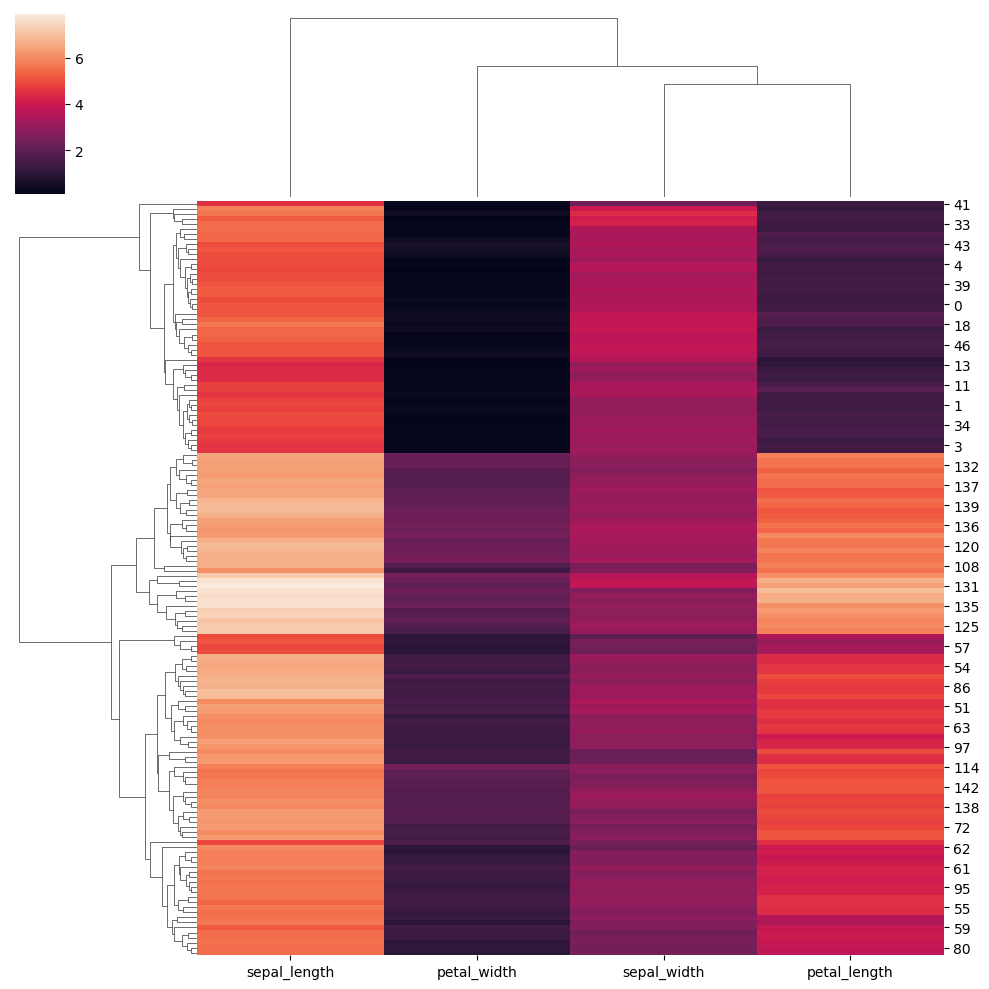

In [136]:
iris = sns.load_dataset("iris")
species = iris.pop("species")
sns.clustermap(iris)